In [ ]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from pathlib import Path

import pandas as pd
import pypangraph as pp
from junction_analysis import pangraph_utils as pu

import plotly.io as pio
pio.renderers.default = "browser" 

from Bio import Phylo

from junction_analysis.consensus import build_edge_index, encode_edge_paths_binary, fitch_ancestral_reconstruction, filter_paths_by_edge_presence, compute_majority_path, consensus_paths_and_assignments, deduplicate_blocks_by_sequence, filter_isolates_by_anchor_count
from junction_analysis.plotting import plot_junction_pangraph_interactive
from junction_analysis.helpers import build_subtree
from junction_analysis.consensus import find_consensus_paths_core, cluster_map_to_dataframe, save_consensus_cache, cluster_isolates_by_core_blocks, cluster_tree_by_branch_length
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, summarize_ambiguous_insertions, load_all_ambiguous_insertions_summaries

In [2]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")
jdf_all

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,...,0.0,0.0,744.000000,0.991064,0.973218,NaN,NaN,NaN,NaN,NaN
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,...,0.0,0.0,777.000000,0.996997,0.990991,True,False,NZ_CP051615.1,NaN,False
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,...,0.0,0.0,1437.000000,0.996997,0.990991,True,False,NZ_AP022362.1,NaN,False
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,0.0,0.0,777.000000,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,...,0.0,0.0,38175.000000,0.996997,0.990991,True,False,NZ_CP032201.1,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,PLTCZQCVRD_f__RYYAQMEJGY_f,3,48,True,3,1,False,1.098612,80,101503,...,3366.0,0.0,7118.870968,0.138971,0.058489,NaN,NaN,NaN,NaN,NaN
514,DSLXSJZSTL_r__KGJXRPELGX_f,2,7,True,2,1,True,0.693147,20,17091,...,0.0,0.0,3420.000000,0.818182,0.800000,NaN,NaN,NaN,NaN,NaN
515,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN
516,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN


## New algorithm that refines current one

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/RYYAQMEJGY_r__ZTHKZYHPIX_f
Processing cluster 0 with 144 isolates


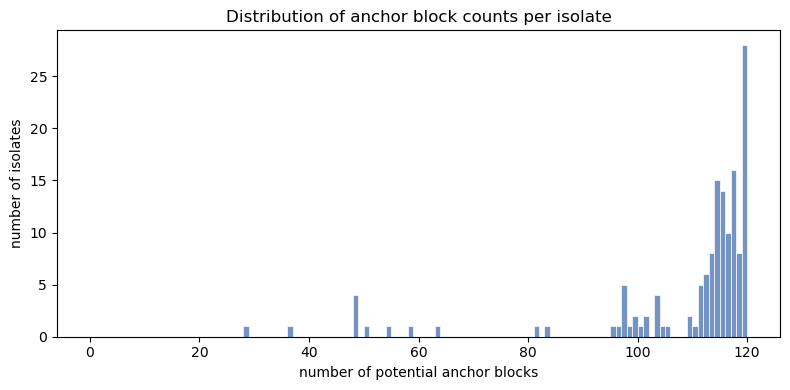

Processing cluster 1 with 1 isolates


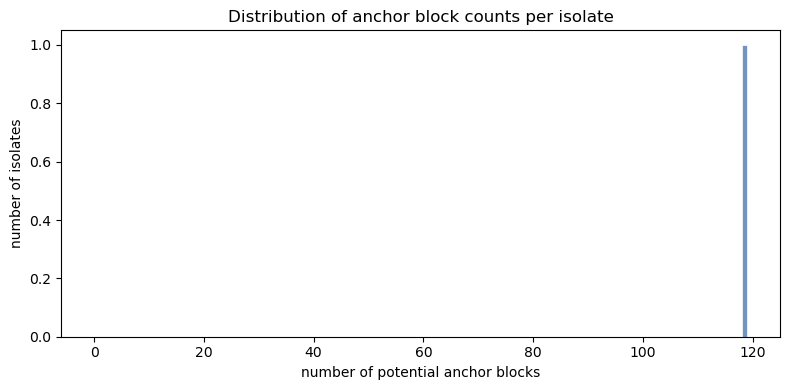

Processing cluster 3 with 1 isolates


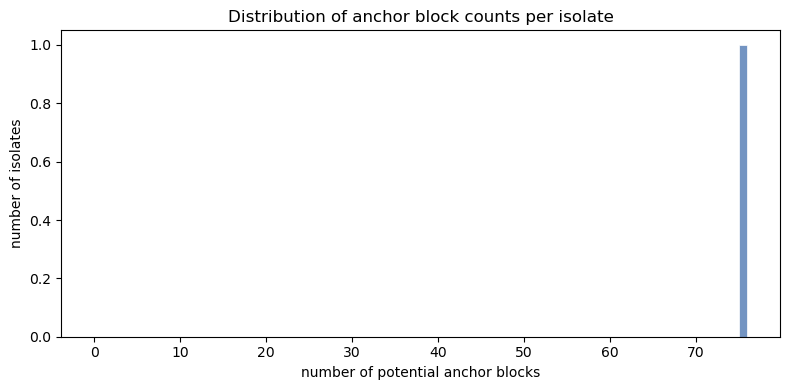

Processing cluster 5 with 17 isolates


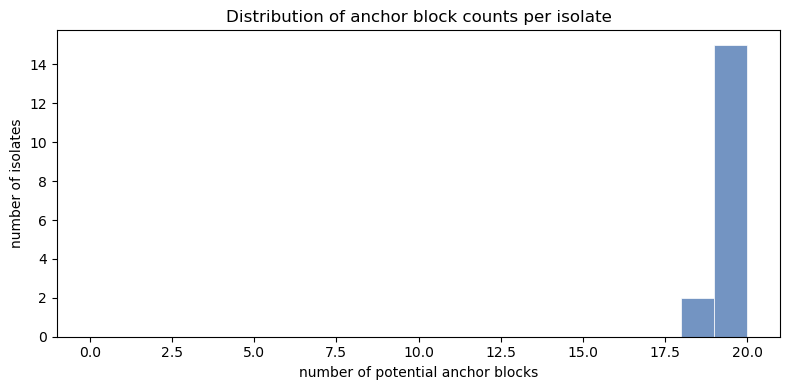

Processing cluster 7 with 1 isolates


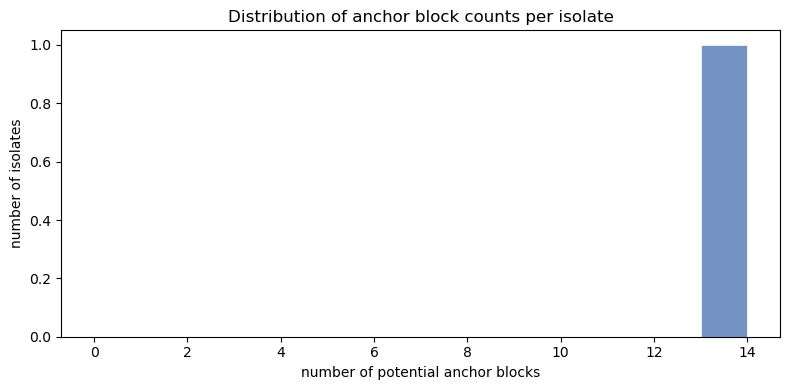

Processing cluster 8 with 52 isolates


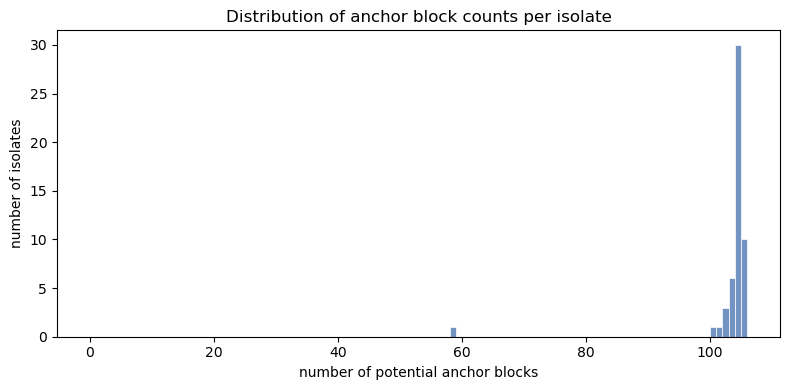

In [ ]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

# define paths based on edges
path_dict = pangraph.to_path_dictionary()
path_dict = {isolate: pu.Path.from_tuple_list(path, 'node') for isolate, path in path_dict.items()}

# add node ids
for isolate, path in path_dict.items():
    for idx, node in enumerate(path.nodes):
        node.nid = pangraph.paths[isolate].nodes[idx]

path_dict = deduplicate_blocks_by_sequence(pangraph, path_dict, junction_name, length_threshold=0.001)

cluster_map, cluster_to_isos, _, _ = cluster_isolates_by_core_blocks(pangraph, path_dict, junction_name, clustering_bl_thresh=0.001)

tree_path = "../config/polished_tree.nwk"
tree = Phylo.read(tree_path, "newick")
tree.rooted = True
consensus_paths = {}

for cl, isolate_list in cluster_to_isos.items():
    path_dict_cluster = {iso: path_dict[iso] for iso in isolate_list}
    print(f"Processing cluster {cl} with {len(isolate_list)} isolates")
    anchor_counts = filter_isolates_by_anchor_count(path_dict_cluster, rare_context_thresh=0.2) 



In [7]:
from scipy.stats import zscore
zscore(anchor_counts)

array([ 0.32296525,  0.0090551 ,  0.32296525,  0.16601017,  0.16601017,
        0.16601017,  0.0090551 ,  0.32296525,  0.16601017,  0.16601017,
        0.16601017,  0.16601017,  0.16601017,  0.32296525,  0.16601017,
       -0.30485505,  0.0090551 ,  0.16601017,  0.16601017,  0.16601017,
        0.16601017,  0.32296525,  0.16601017,  0.16601017,  0.16601017,
        0.16601017, -0.14789997,  0.16601017,  0.0090551 ,  0.16601017,
       -0.46181012,  0.0090551 ,  0.16601017,  0.16601017, -0.14789997,
        0.16601017, -7.05392322,  0.0090551 ,  0.32296525,  0.16601017,
        0.16601017,  0.16601017,  0.32296525,  0.16601017,  0.16601017,
        0.32296525,  0.32296525,  0.16601017,  0.32296525, -0.14789997,
        0.16601017,  0.16601017])

In [6]:
cluster_to_isos

defaultdict(list,
            {0: ['NZ_CP102061.1',
              'NZ_OW849064.1',
              'NZ_CP107143.1',
              'NZ_CP015085.1',
              'NZ_CP107155.1',
              'NZ_CP059130.1',
              'NZ_OY019088.1',
              'NZ_CP080116.1',
              'NZ_CP019015.1',
              'NZ_CP107120.1',
              'NZ_CP096110.1',
              'NZ_CP029420.1',
              'NZ_CP124517.1',
              'NZ_CP018991.1',
              'NZ_CP107117.1',
              'NZ_CP107134.1',
              'NZ_CP107137.1',
              'NZ_CP013835.1',
              'NZ_CP051661.1',
              'NZ_CP124415.1',
              'NZ_CP054219.1',
              'NZ_CP018979.1',
              'NZ_LR890693.1',
              'NZ_CP107147.1',
              'NZ_CP010876.1',
              'NZ_CP021689.1',
              'NZ_CP124349.1',
              'NZ_CP076693.1',
              'NZ_CP014316.1',
              'NZ_CP023844.1',
              'NZ_CP124420.1',
              'NZ_

## Try new algorithm to get consensus path by always considering local context of three isolates

In [6]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

# define paths based on edges
path_dict = pangraph.to_path_dictionary()
path_dict = {isolate: pu.Path.from_tuple_list(path, 'node') for isolate, path in path_dict.items()}

# add node ids
for isolate, path in path_dict.items():
    for idx, node in enumerate(path.nodes):
        node.nid = pangraph.paths[isolate].nodes[idx]

cluster_map, cluster_to_isos, _, _ = cluster_isolates_by_core_blocks(pangraph, path_dict, junction_name, clustering_bl_thresh=0.001)

edge_path_dict = {isolate: pu.EdgePath.from_path(path) for isolate, path in path_dict.items()}


tree_path = "../config/polished_tree.nwk"
tree = Phylo.read(tree_path, "newick")
tree.rooted = True
consensus_paths = {}

for cl, isolate_list in cluster_to_isos.items():
    edge_path_dict_cluster = {iso: edge_path_dict[iso] for iso in isolate_list if iso in edge_path_dict}
    path_dict_cluster = {iso: path_dict[iso] for iso in isolate_list if iso in path_dict}
            
    edges, edge2idx = build_edge_index(edge_path_dict_cluster)
    binary_encodings = encode_edge_paths_binary(edge_path_dict_cluster, edge2idx)

    subtree = build_subtree(tree, isolate_list)
    fitch_ancestral_reconstruction(subtree, binary_encodings)
    root_states = subtree.root._state_sets  # list of {0}/{1}, one per edge  
    
    filtered_paths = filter_paths_by_edge_presence(                                                                                                   
          path_dict_cluster,
          edge_path_dict_cluster,                                                                                                                       
          edges,
          root_states,                                                                                                                       
          edge2idx,
          junction_name,
          cl,
    )
    consensus_path = compute_majority_path(filtered_paths)
    consensus_paths[cl] = consensus_path

consensus_paths_plotting, assignment_df_plotting, _ = consensus_paths_and_assignments(consensus_paths, cluster_map)
                                                                                                                                                        
fig = plot_junction_pangraph_interactive(
      pangraph,                                                                                                                                         
      show_consensus=True,
      consensus_paths=consensus_paths_plotting,
      assignments=assignment_df_plotting,
      order="tree",
      cluster_map=cluster_map,                                                                                                                     
      )
fig.show()

25 / 144 isolates share the majority path
1 / 1 (single isolate)
1 / 1 (single isolate)
13 / 17 isolates share the majority path
1 / 1 (single isolate)
37 / 52 isolates share the majority path


In [10]:
consensus_paths[0]

[16671105780806995519|+]_[10958655627444534111|+]_[3419103275029521940|+]_[1448964389002043948|+]_[7166485448600219032|+]_[10480880799551222441|+]_[9943278599560102111|+]_[7385292223686217602|+]_[13612719202651021848|-]_[3226134370544314880|-]_[17141892380880723886|-]_[16424442392483324144|-]_[6800119766726695319|+]_[5670023643096029701|+]_[11734174143264340999|+]_[14230977707636736595|+]_[15169038317952353904|+]_[6912564871896832629|+]_[1833494430068775247|+]_[441542311555414356|+]_[578008595963632427|+]_[13050355685719842709|+]_[16400092613407614919|+]_[5598563553016563611|+]_[6523613490405440663|+]_[5285753434584984164|-]_[11300668210740262185|-]_[5339633743814445085|-]_[13388509215143776072|-]_[7110182631703495678|+]_[951767945673275678|+]_[8987038859492738001|+]_[15360012090594632702|+]_[8530574476422229527|+]_[12363789723620449651|+]_[3925988953842971952|+]_[11989555523476015498|+]_[8828234920825701013|+]_[9664989659593652885|+]_[1377680073246787056|+]_[9335326342918343692|+]_[15

In [13]:
edge_path_dict['NZ_LS999560.1']

[16671105780806995519|+] <--> [10958655627444534111|+] (#1) -> [10958655627444534111|+] <--> [3419103275029521940|+] (#1) -> [3419103275029521940|+] <--> [1448964389002043948|+] (#1) -> [1448964389002043948|+] <--> [7166485448600219032|+] (#1) -> [7166485448600219032|+] <--> [10480880799551222441|+] (#1) -> [10480880799551222441|+] <--> [9943278599560102111|+] (#1) -> [9943278599560102111|+] <--> [7385292223686217602|+] (#1) -> [7385292223686217602|+] <--> [13612719202651021848|-] (#1) -> [13612719202651021848|-] <--> [3226134370544314880|-] (#1) -> [3226134370544314880|-] <--> [17141892380880723886|-] (#1) -> [17141892380880723886|-] <--> [16424442392483324144|-] (#1) -> [16424442392483324144|-] <--> [6800119766726695319|+] (#1) -> [6800119766726695319|+] <--> [5670023643096029701|+] (#1) -> [5670023643096029701|+] <--> [11734174143264340999|+] (#1) -> [11734174143264340999|+] <--> [14230977707636736595|+] (#1) -> [14230977707636736595|+] <--> [15169038317952353904|+] (#1) -> [1516903

In [8]:
for i in range(1, len(consensus_paths_plotting) + 1):
    insertions, ambiguous_insertions, deletions, inversions, translocations, context_stats_df = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
    break

Insertions:
NZ_CP102061.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP102061.1 INSERTED: [2150995670991051021|+]
NZ_CP080116.1 INSERTED: [9498745749412710955|+]
NZ_CP080116.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP080116.1 INSERTED: [2150995670991051021|+]
NZ_CP080116.1 INSERTED: [13388509215143776072|+]
NZ_CP080116.1 INSERTED: [5285753434584984164|+]
NZ_CP124517.1 INSERTED: [4892779445509988905|-]_[8843624255696360543|-]_[5285753434584984164|-]_[11300668210740262185|-]_[5339633743814445085|-]_[13388509215143776072|-]
NZ_CP124517.1 INSERTED: [13388509215143776072|+]
NZ_CP124517.1 INSERTED: [5285753434584984164|+]
NZ_CP019015.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP019015.1 INSERTED: [2150995670991051021|+]
NZ_CP019015.1 INSERTED: [13388509215143776072|+]
NZ_CP019015.1 INSERTED: [5285753434584984164|+]
NZ_CP018991.1 INSERTED: [17885250183886920782|+]
NZ_CP018991.1 INSERTED: [2150995670991051021|+]
NZ_CP018991.1 INSERTED: [

In [10]:
cluster_to_isos

defaultdict(list,
            {0: ['NZ_CP102061.1',
              'NZ_OW849064.1',
              'NZ_CP107143.1',
              'NZ_CP015085.1',
              'NZ_CP107155.1',
              'NZ_CP059130.1',
              'NZ_OY019088.1',
              'NZ_CP080116.1',
              'NZ_CP019015.1',
              'NZ_CP107120.1',
              'NZ_CP096110.1',
              'NZ_CP029420.1',
              'NZ_CP124517.1',
              'NZ_CP018991.1',
              'NZ_CP107117.1',
              'NZ_CP107134.1',
              'NZ_CP107137.1',
              'NZ_CP013835.1',
              'NZ_CP051661.1',
              'NZ_CP124415.1',
              'NZ_CP054219.1',
              'NZ_CP018979.1',
              'NZ_LR890693.1',
              'NZ_CP107147.1',
              'NZ_CP010876.1',
              'NZ_CP021689.1',
              'NZ_CP124349.1',
              'NZ_CP076693.1',
              'NZ_CP014316.1',
              'NZ_CP023844.1',
              'NZ_CP124420.1',
              'NZ_

In [7]:
edge_path_dict['NC_022648.1']

[16671105780806995519|+] <--> [10958655627444534111|+] (#1) -> [10958655627444534111|+] <--> [3419103275029521940|+] (#1) -> [3419103275029521940|+] <--> [1448964389002043948|+] (#1) -> [1448964389002043948|+] <--> [7166485448600219032|+] (#1) -> [7166485448600219032|+] <--> [10480880799551222441|+] (#1) -> [10480880799551222441|+] <--> [9943278599560102111|+] (#1) -> [9943278599560102111|+] <--> [7385292223686217602|+] (#1) -> [7385292223686217602|+] <--> [13612719202651021848|-] (#1) -> [13612719202651021848|-] <--> [3226134370544314880|-] (#1) -> [3226134370544314880|-] <--> [17141892380880723886|-] (#1) -> [17141892380880723886|-] <--> [16424442392483324144|-] (#1) -> [16424442392483324144|-] <--> [6800119766726695319|+] (#1) -> [6800119766726695319|+] <--> [5670023643096029701|+] (#1) -> [5670023643096029701|+] <--> [11734174143264340999|+] (#1) -> [11734174143264340999|+] <--> [14230977707636736595|+] (#1) -> [14230977707636736595|+] <--> [15169038317952353904|+] (#1) -> [1516903

In [9]:
path_dict['NZ_CP102061.1'].nodes[0].nid

14721554060296838207

## Can sequence similarity information help to resolve duplicated blocks?
It can help in some cases, especially if we build trees on all blocks with a length > 500 bp already but it doesnt fully solve the duplication problem.
- the fact that these blocks could be split doesnt necessarily mean that specifically duplicates will be split
- we can't say anything about short blocks and they are the most problematic
- not all long blocks differ enough

In [24]:
records = []
base_dir = "../results/block_alignments"
                                                                                                                                                                                                                                            
for junction in jdf_all['junction_name']:                                                                                                                                                                                                   
    csv_path = os.path.join(base_dir, junction, f"{junction}_alignment_stats.csv")
    if not os.path.exists(csv_path):                                                                                                                                                                                                        
        continue                                                                                                                                                                                                                            
    df = pd.read_csv(csv_path)
    dup = df[df['duplicated'] == True]                                                                                                                                                                                                      
    for _, row in dup.iterrows():
        records.append({
            'junction_name': junction,                                                                                                                                                                                                      
            'block_id': row['block_id'],
            'len': row['len'],                                                                                                                                                                                                              
            'avg_pairwise_dist': row['avg_pairwise_dist'],
        })                                                                                                                                                                                                                                  

summary_df = pd.DataFrame(records)                                                                                                                                                                                                          
summary_df     

,junction_name,block_id,len,avg_pairwise_dist
0,JJRRWBDVGH_f__TFKJQKVUKX_f,1101536001531877591,175,0.055947
1,JJRRWBDVGH_f__TFKJQKVUKX_f,2251987336623189867,100,0.028571
2,JJRRWBDVGH_f__TFKJQKVUKX_f,3132791157853211795,195,0.066330
3,JJRRWBDVGH_f__TFKJQKVUKX_f,3145149207096864253,122,0.029339
4,JJRRWBDVGH_f__TFKJQKVUKX_f,4866283470688286449,119,0.042347
...,...,...,...,...
405,YUOECYBHUS_f__ZTHKZYHPIX_f,1528420688200569391,1912,0.105181
406,YUOECYBHUS_f__ZTHKZYHPIX_f,3870718793672684742,768,0.043194
407,YUOECYBHUS_f__ZTHKZYHPIX_f,3986164421478461937,454,0.000000
408,YUOECYBHUS_f__ZTHKZYHPIX_f,11739289533746856500,793,0.006574


Percentage of duplicated blocks with length < 200: 25.61%
Percentage of duplicated blocks with length < 500: 57.56%
Percentage of duplicated blocks with length < 1000: 78.54%


<Axes: >

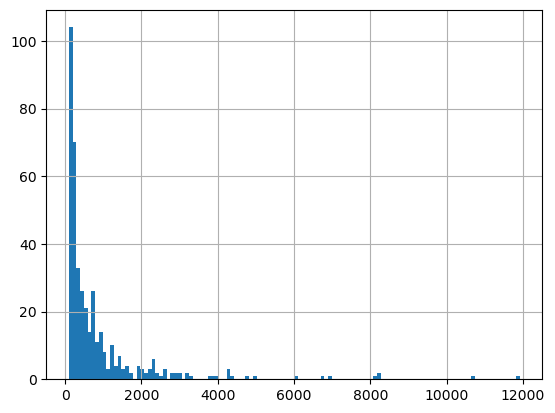

In [20]:
print(f"Percentage of duplicated blocks with length < 200: {len(summary_df[summary_df['len'] < 200]) / len(summary_df) * 100:.2f}%")
print(f"Percentage of duplicated blocks with length < 500: {len(summary_df[summary_df['len'] < 500]) / len(summary_df) * 100:.2f}%")
print(f"Percentage of duplicated blocks with length < 1000: {len(summary_df[summary_df['len'] < 1000]) / len(summary_df) * 100:.2f}%")
summary_df['len'].hist(bins=120)

<Axes: >

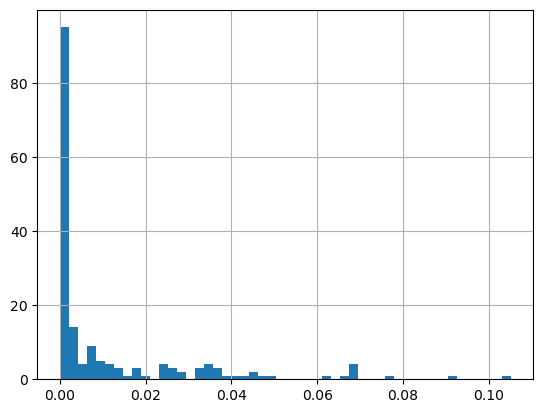

In [16]:
summary_df[summary_df['len'] > 500].avg_pairwise_dist.hist(bins=50)

In [19]:
print(f"{len(summary_df[(summary_df['len'] > 500) & (summary_df['avg_pairwise_dist'] > 0.001)]) / len(summary_df[summary_df['len'] > 500]) * 100:.2f}% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)")
print(f"{len(summary_df[(summary_df['len'] > 1000) & (summary_df['avg_pairwise_dist'] > 0.001)]) / len(summary_df[summary_df['len'] > 1000]) * 100:.2f}% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)")

54.02% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)
47.73% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)


Consider all blocks
- if we further split blocks to resolve duplicates we have to also split non-duplicated blocks, this might then just show HR clustering signal or split blocks within clusters
- do we want this complication?

In [27]:
records = []
base_dir = "../results/block_alignments"
                                                                                                                                                                                                                                            
for junction in jdf_all['junction_name']:                                                                                                                                                                                                   
    csv_path = os.path.join(base_dir, junction, f"{junction}_alignment_stats.csv")
    if not os.path.exists(csv_path):                                                                                                                                                                                                        
        continue                                                                                                                                                                                                                            
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        records.append({
            'junction_name': junction,                                                                                                                                                                                                      
            'block_id': row['block_id'],
            'len': row['len'],                                                                                                                                                                                                              
            'avg_pairwise_dist': row['avg_pairwise_dist'],
        })                                                                                                                                                                                                                                  

summary_df_all = pd.DataFrame(records)                                                                                                                                                                                                          
summary_df_all    

,junction_name,block_id,len,avg_pairwise_dist
0,HUTOPWFGVH_f__WJBYSSJHSE_f,4119167410460397689,16280,0.000098
1,HUTOPWFGVH_f__WJBYSSJHSE_f,7811279214181103925,777,0.000000
2,HUTOPWFGVH_f__WJBYSSJHSE_f,8652915928890312090,1698,0.006795
3,HUTOPWFGVH_f__WJBYSSJHSE_f,10223321923686949189,198,0.000000
4,HUTOPWFGVH_f__WJBYSSJHSE_f,11271243518245960494,711,0.000000
...,...,...,...,...
5132,YUOECYBHUS_f__ZTHKZYHPIX_f,15301843099917212677,287,0.000000
5133,YUOECYBHUS_f__ZTHKZYHPIX_f,15685664920164088488,12281,0.000000
5134,YUOECYBHUS_f__ZTHKZYHPIX_f,15870816832931575866,1945,0.000000
5135,YUOECYBHUS_f__ZTHKZYHPIX_f,16141324844737295108,1286,0.069207


Percentage of blocks with length < 200: 10.53%
Percentage of blocks with length < 500: 28.05%
Percentage of blocks with length < 1000: 49.11%


<Axes: >

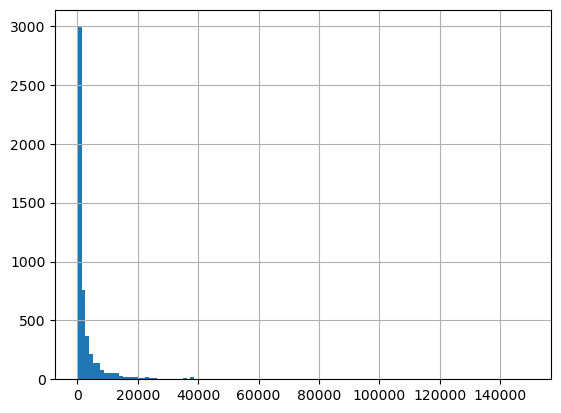

In [30]:
print(f"Percentage of blocks with length < 200: {len(summary_df_all[summary_df_all['len'] < 200]) / len(summary_df_all) * 100:.2f}%")
print(f"Percentage of blocks with length < 500: {len(summary_df_all[summary_df_all['len'] < 500]) / len(summary_df_all) * 100:.2f}%")
print(f"Percentage of blocks with length < 1000: {len(summary_df_all[summary_df_all['len'] < 1000]) / len(summary_df_all) * 100:.2f}%")
summary_df_all['len'].hist(bins=120)

33.49% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)
29.90% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)


<Axes: >

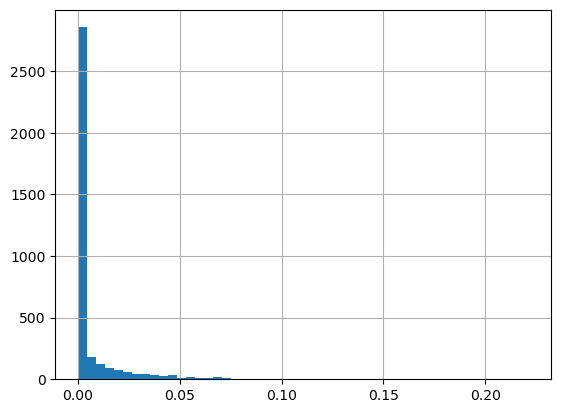

In [32]:
print(f"{len(summary_df_all[(summary_df_all['len'] > 500) & (summary_df_all['avg_pairwise_dist'] > 0.001)]) / len(summary_df_all[summary_df_all['len'] > 500]) * 100:.2f}% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)")
print(f"{len(summary_df_all[(summary_df_all['len'] > 1000) & (summary_df_all['avg_pairwise_dist'] > 0.001)]) / len(summary_df_all[summary_df_all['len'] > 1000]) * 100:.2f}% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)")

summary_df_all[summary_df_all['len'] > 500].avg_pairwise_dist.hist(bins=50)